## Simulations

In [26]:
from modules import RSCGenerator, SCMSimulator, RandomSeeding
import numpy as np
def sim_rho(lam_d,
            N = 2000,
            k_avg = 20,
            k_d_avg = 6,
            mu = 0.1,
            rho_0 = 0.4,
            t_max = 2000,
            t_avg = 100,
            lambda_vals = np.linspace(0.0, 2.5, 30)
            ):

    generator = RSCGenerator(k_avg=k_avg, k_delta_avg=k_d_avg, N=N)
    links, triangles = generator.generate(seed=42)
    rho_stars = []
    beta_d = (lam_d * mu) / k_d_avg

    for lam in lambda_vals:
        beta = (lam * mu) / k_avg
        
        if beta > 1.0 or beta_d > 1.0:
            raise ValueError("Calculated beta exceeds 1.0. Decrease mu.")
            
        seeder = RandomSeeding(N, rho_0)
        initial_infected = seeder.seed()
        
        sim = SCMSimulator(
            links=links, 
            triangles=triangles, 
            initial_infected=initial_infected, 
            beta=beta, 
            beta_delta=beta_d, 
            mu=mu
        )
        
        rho_history = sim.run(t_max)

        if rho_history[-1] == 0.0:
            rho_star = 0.0
        else:
            rho_star = np.mean(rho_history[-t_avg:])
            
        rho_stars.append(rho_star)
    return np.array(rho_stars)

## Analytical

In [27]:
# Analytical Curves
def mf_rho(lam, lam_d):
    """
    Calculates the mean-field analytical steady states of the SCM
    p = (lam_d - lam +- sqrt((lam - lam_d)^2 -4lam_d(1-lam))) / (2lam_d)
    """
    if lam_d == 0:
        return 1 - 1 / lam

    discriminant = (lam - lam_d)**2 - 4 * lam_d * (1 - lam)
    sqrt_term = np.sqrt(discriminant.astype(complex))
    rho = (lam_d - lam + sqrt_term) / (2 * lam_d)
    rho = np.where(np.imag(rho) != 0, 0, rho)
            
    return rho.real

## Plotting

Sampling edges with p_1 = 0.00402617
Edges sampled: 7962/7962
Sampling triangles with p_delta = 0.00000300
Triangles sampled: 4051/4051
Sampling edges with p_1 = 0.00402617
Edges sampled: 7962/7962
Sampling triangles with p_delta = 0.00000300
Triangles sampled: 4051/4051
Sampling edges with p_1 = 0.00402617
Edges sampled: 7962/7962
Sampling triangles with p_delta = 0.00000300
Triangles sampled: 4051/4051


/tmp/ipykernel_24468/4098566725.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', framealpha=1, edgecolor='black')


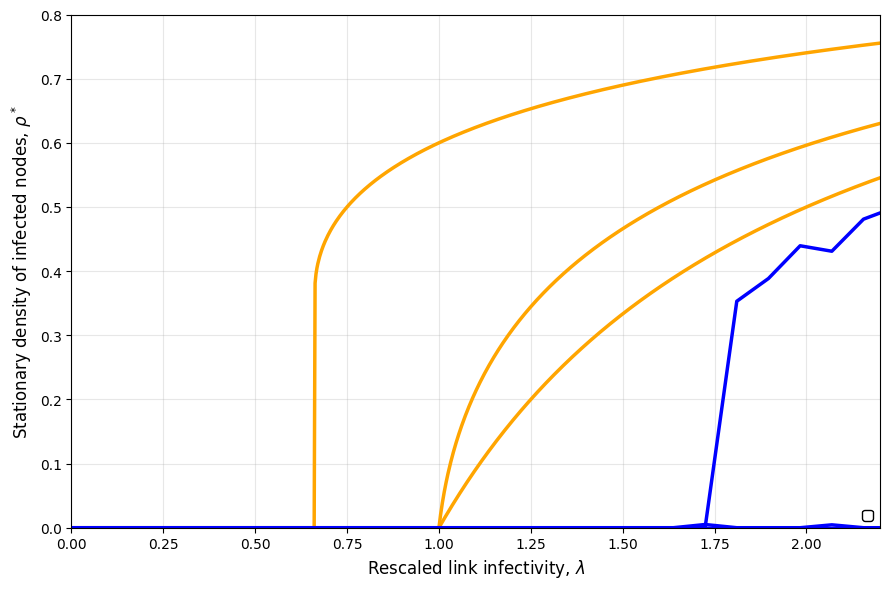

In [28]:
import matplotlib.pyplot as plt

lambdas_mf = np.linspace(0.01, 2.5, 1000)
mf_rho_0 = mf_rho(lambdas_mf, 0.0)
mf_rho_08 = mf_rho(lambdas_mf, 0.8)
mf_rho_25 = mf_rho(lambdas_mf, 2.5)

# Simulation Curves
lambdas_sim = np.linspace(0.0, 2.5, 30)
sim_rho_0 = sim_rho(lam_d=0.0, lambda_vals=lambdas_sim)
sim_rho_08 = sim_rho(lam_d=0.8, lambda_vals=lambdas_sim)
sim_rho_25 = sim_rho(lam_d=2.5, lambda_vals=lambdas_sim)

# Plot
plt.figure(figsize=(9, 6))
plt.plot(lambdas_mf, mf_rho_0, color='orange', lw=2.5)
plt.plot(lambdas_mf, mf_rho_08, color='orange', lw=2.5)
plt.plot(lambdas_mf, mf_rho_25, color='orange', lw=2.5)

plt.plot(lambdas_sim, sim_rho_0, color='blue', lw=2.5)
plt.plot(lambdas_sim, sim_rho_08, color='blue', lw=2.5)
plt.plot(lambdas_sim, sim_rho_25, color='blue', lw=2.5)

plt.xlim(0, 2.2)
plt.ylim(0, 0.8)
plt.xlabel(r'Rescaled link infectivity, $\lambda$', fontsize=12)
plt.ylabel(r'Stationary density of infected nodes, $\rho^*$', fontsize=12)
plt.legend(loc='lower right', framealpha=1, edgecolor='black')
plt.grid(alpha=0.3)
plt.tight_layout()

# Save the plot
plt.savefig('analytical_curves.png', dpi=300)
plt.show()